# Shelving Isolation With a Multilevel Sideband


This notebook rewrites `examples/shelving_isolation_demo.py` as a short study of shelving. We prepare a superposition with population in `|e,0>` and `|f,0>`, then use a `gf` red sideband to move only the `|f,0>` component into the cavity while leaving the shelved `|e,0>` population isolated.

The physical point is selective access: multilevel structure lets us move one branch of the wavefunction while protecting another branch from the same control tone.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    SequenceCompiler,
    SidebandDriveSpec,
    SimulationConfig,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    compute_shelving_leakage,
    simulate_sequence,
    subsystem_level_population,
)
from tutorials.tutorial_support import GHz, MHz, ns


## Physics / model definition


In [2]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi=MHz(-0.8),
    kerr=0.0,
    n_cav=4,
    n_tr=3,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
duration_s = 80.0 * ns
amplitude_rad_s = np.pi / (2.0 * duration_s)

initial_state = (
    np.sqrt(0.4) * model.basis_state(1, 0)
    + np.sqrt(0.6) * model.basis_state(2, 0)
).unit()


## Pulse / sequence construction


In [3]:
omega_sb = model.sideband_transition_frequency(
    cavity_level=0,
    lower_level=0,
    upper_level=2,
    sideband="red",
    frame=frame,
)
pulses, drive_ops, pulse_meta = build_sideband_pulse(
    SidebandDriveSpec(mode="storage", lower_level=0, upper_level=2, sideband="red"),
    duration_s=duration_s,
    amplitude_rad_s=amplitude_rad_s,
    sigma_fraction=0.18,
    channel="sb",
    carrier=carrier_for_transition_frequency(omega_sb),
    label="gaussian_gf_sideband",
)
compiled = SequenceCompiler(dt=1.0 * ns).compile(pulses, t_end=duration_s)
print("Pulse metadata:", pulse_meta)


Pulse metadata: {'mapping': 'Effective multilevel sideband drive using the structured SidebandDriveSpec target.', 'duration_s': 8e-08, 'amplitude_rad_s': 19634954.084936205, 'carrier': 1382300767.579509, 'phase': 0.0, 'envelope': 'normalized_gaussian', 'sideband_target': {'mode': 'storage', 'lower_level': 0, 'upper_level': 2, 'sideband': 'red'}}


## Simulation


In [4]:
result = simulate_sequence(
    model,
    compiled,
    initial_state,
    drive_ops,
    config=SimulationConfig(frame=frame),
)

initial_plot = np.asarray([0.4, 0.6, 0.0], dtype=float)
final_plot = np.asarray(
    [
        subsystem_level_population(result.final_state, "transmon", 1),
        abs(model.basis_state(2, 0).overlap(result.final_state)) ** 2,
        abs(model.basis_state(0, 1).overlap(result.final_state)) ** 2,
    ],
    dtype=float,
)

shelving_leakage = compute_shelving_leakage(initial_state, result.final_state, shelved_level=1)
print("Shelving leakage:", shelving_leakage)


Shelving leakage: 1.659755219030057e-05


## Analysis / visualization


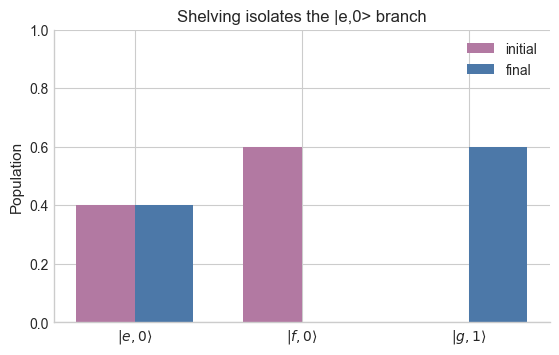

In [5]:
labels = [r"$|e,0\rangle$", r"$|f,0\rangle$", r"$|g,1\rangle$"]
x = np.arange(len(labels), dtype=float)
width = 0.35

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.bar(x - width / 2.0, initial_plot, width=width, label="initial", color="#B279A2")
ax.bar(x + width / 2.0, final_plot, width=width, label="final", color="#4C78A8")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Population")
ax.set_title("Shelving isolates the |e,0> branch")
ax.legend(loc="best")
plt.show()


## Interpretation


The `|e,0>` population stays nearly unchanged because the chosen sideband couples `|f,0>` to `|g,1>` and does not directly address the shelved `|e,0>` branch. The leakage metric quantifies how well that isolation worked.

This is a small but practical example of why multilevel transmon structure matters: selective control often depends on choosing which ladder transition participates in the bosonic transfer.


## Variations / exercises


- Increase the pulse amplitude to see when the shelved branch starts to leak appreciably.
- Compare Gaussian and square sideband envelopes.
- Add weak dissipation to see whether shelving remains useful once the protocol is no longer unitary.
